# ML Project

## Data Modeling

### Ranking Problem (First Problem)

In [129]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor

# Load the dataset
file_path = '../dataset_for_modeling/features_for_ranking.csv'
rank_teams = pd.read_csv(file_path)

feature_columns = [
    "player_awards", "net_rating", "off_eff", "def_eff", "home_win_pct",
    "away_win_pct", "reb_dif", "conf_win_pct", "ast_dif", "blk_dif",
    "pf_dif", "coach_awards", "efg_pct", "win_pct", "pts_per_poss",
    "ts_pct", "eff_x_pace", "net_four_factors", "pyth_wins"
]

# Add 'rank' and 'confID' for lagging and grouping
base_columns = feature_columns + ['rank', 'confID']

# Ensure data is sorted by team and year for correct lagging
rank_teams = rank_teams.sort_values(by=['tmID', 'year'])


In [130]:
# Create Lag-1 Features (Last Year's Stats)
lag1_feature_names = [f"{col}_lag1" for col in base_columns]
rank_teams[lag1_feature_names] = rank_teams.groupby('tmID')[base_columns].shift(1)

# Create 3-Year Rolling Avg Features
cols_to_weight = feature_columns + ['rank']
avg3yr_feature_names = [f"{col}_avg3yr_lag" for col in cols_to_weight]

# Define the weighted average function
def weighted_avg(series):
    """
    Calculates a weighted average adapting to available history (1, 2, or 3 years).
    Weights: 0.5 (Last Year), 0.3 (2 Years Ago), 0.2 (3 Years Ago).
    """
    weights = np.array([0.2, 0.3, 0.5])
    
    # Convert series to array to handle NaNs safely
    s = np.array(series)
    mask = ~np.isnan(s)
    
    # If no valid data exists in the window, return NaN
    if not np.any(mask):
        return np.nan
        
    # Adjust weights to the window size and available data
    w = weights[-len(s):]
    valid_s = s[mask]
    valid_w = w[mask]
    
    # Normalize by the sum of valid weights
    return np.sum(valid_s * valid_w) / np.sum(valid_w)

# Calculate rolling average on the lag-1 features
# min_periods=1 ensures we calculate averages even for teams with short history
rolling_avg_features = rank_teams.groupby('tmID')[[f"{col}_lag1" for col in cols_to_weight]] \
                                 .rolling(window=3, min_periods=1) \
                                 .apply(weighted_avg, raw=True)

# Align the rolling average index
rank_teams[avg3yr_feature_names] = rolling_avg_features.reset_index(level=0, drop=True)

# Clean Data
# Only drop rows if Lag-1 data is missing.
# This keeps teams that have Year N-1 data but lack Year N-2 or N-3.
model_df = rank_teams.dropna(subset=lag1_feature_names)

print(f"Original shape: {rank_teams.shape}, Model-ready shape: {model_df.shape}")


Original shape: (142, 65), Model-ready shape: (122, 65)


In [131]:
# The target is always the rank of the CURRENT year
target_col = 'rank'

# Experiment A: Use only last year's stats
features_lag1 = [f"{col}_lag1" for col in feature_columns] + ['rank_lag1']

# Experiment B: Use only the 3-year average stats
features_avg3yr = [f"{col}_avg3yr_lag" for col in feature_columns] + ['rank_avg3yr_lag']

# Experiment C: Use both sets
features_combined = features_lag1 + features_avg3yr

feature_sets = {
    "Lag 1 Only": features_lag1,
    "Avg 3-Year Only": features_avg3yr,
    "Combined": features_combined
}


In [132]:
TEST_YEAR = 10
VALIDATION_YEAR = 9

# Train: All years BEFORE the validation year
train_df = model_df[model_df['year'] < VALIDATION_YEAR] # Years 2-8
y_train = train_df[target_col]

# Validate: Only the validation year
val_df = model_df[model_df['year'] == VALIDATION_YEAR] # Year 9
y_val = val_df[target_col]

# Test: Only the test year
test_df = model_df[model_df['year'] == TEST_YEAR] # Year 10
y_test = test_df[target_col]

print(f"Training observations: {len(train_df)}")
print(f"Validation observations: {len(val_df)}")
print(f"Test observations: {len(test_df)}")


Training observations: 96
Validation observations: 13
Test observations: 13


In [133]:
# Get the baseline prediction (last year's rank)
y_pred_baseline = val_df['rank_lag1']

y_pred_baseline.head()

# Evaluate baseline on the Validation set
mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
spearman_baseline, _ = spearmanr(y_val, y_pred_baseline)

print("--- Baseline Model (on Validation Set) ---")
print(f"  MAE: {mae_baseline:.4f}")
print(f"  Spearman Rank: {spearman_baseline:.4f}")


--- Baseline Model (on Validation Set) ---
  MAE: 1.5385
  Spearman Rank: 0.4008


In [134]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for fs_name, fs_cols in feature_sets.items():
    print(f"\n--- Testing Feature Set: {fs_name} ---")
    
    # Define X data based on the current feature set
    X_train = train_df[fs_cols]
    X_val = val_df[fs_cols]

    # Scale data (important for Linear Regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    for name, model in models.items():
        # Fit model
        if name == 'Linear Regression':
            model.fit(X_train_scaled, y_train)
            y_pred_val = model.predict(X_val_scaled)
        else:
            model.fit(X_train, y_train) # Tree models don't require scaling
            y_pred_val = model.predict(X_val)
        
        # Evaluate model
        mae = mean_absolute_error(y_val, y_pred_val)
        spearman_corr, _ = spearmanr(y_val, y_pred_val)
        
        print(f"  Model: {name}")
        print(f"    MAE: {mae:.4f} (Baseline: {mae_baseline:.4f})")
        print(f"    Spearman: {spearman_corr:.4f} (Baseline: {spearman_baseline:.4f})")
        
        results.append((fs_name, name, mae, spearman_corr))

best_result = max(results, key=lambda item: item[2])
best_fs_name, best_model_name, best_mae, best_spearman = best_result

print(f"\n--- Best Model from Validation (based on MAE) ---")
print(f"  Feature Set: {best_fs_name}")
print(f"  Model: {best_model_name}")
print(f"  Spearman: {best_spearman:.4f}")



--- Testing Feature Set: Lag 1 Only ---
  Model: Linear Regression
    MAE: 2.0144 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.6892 (Baseline: 1.5385)
    Spearman: 0.1551 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.9915 (Baseline: 1.5385)
    Spearman: 0.1108 (Baseline: 0.4008)

--- Testing Feature Set: Avg 3-Year Only ---
  Model: Linear Regression
    MAE: 1.7001 (Baseline: 1.5385)
    Spearman: 0.0277 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.7454 (Baseline: 1.5385)
    Spearman: -0.0526 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 1.7169 (Baseline: 1.5385)
    Spearman: 0.0693 (Baseline: 0.4008)

--- Testing Feature Set: Combined ---
  Model: Linear Regression
    MAE: 1.9841 (Baseline: 1.5385)
    Spearman: 0.1634 (Baseline: 0.4008)
  Model: Random Forest
    MAE: 1.8400 (Baseline: 1.5385)
    Spearman: -0.0319 (Baseline: 0.4008)
  Model: Gradient Boosting
    MAE: 2.0649 (Baseline: 1.5385)
    Sp

In [135]:
# Prepare Data (Train + Validation combined for Cross-Validation)
# We use the best feature set found in the previous step
best_features = feature_sets[best_fs_name]

X_train_full = pd.concat([train_df[best_features], val_df[best_features]])
y_train_full = pd.concat([y_train, y_val])

# Define Models and their Hyperparameter Grids
model_configs = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300, 500],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ['sqrt', 'log2', None]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 300, 500, 1000],
            "model__learning_rate": [0.005, 0.01, 0.05, 0.1],
            "model__max_depth": [3, 4, 5],
            "model__subsample": [0.7, 0.8, 0.9, 1.0]
        }
    },
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            "model__alpha": [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "model__C": [0.1, 1, 10, 100, 1000],
            "model__kernel": ['linear', 'rbf', 'poly'],
            "model__epsilon": [0.01, 0.1, 0.2, 0.5],
            "model__gamma": ['scale', 'auto', 0.1, 0.01]
        }
    },
    "AdaBoost": {
        "model": AdaBoostRegressor(random_state=42),
        "params": {
            "model__n_estimators": [50, 100, 300, 500],
            "model__learning_rate": [0.001, 0.01, 0.1, 1.0],
            "model__loss": ['linear', 'square', 'exponential']
        }
    },
    "Linear Regression": {
        "model": LinearRegression(),
        "params": {
            "model__fit_intercept": [True, False]
        }
    }
}

# Run Systematic Grid Search for all Models
results = []
best_overall_model = None
best_overall_score = -float("inf") # Since we use neg_MAE, closer to 0 is better

print(f"--- Starting Extensive Grid Search on {len(model_configs)} Models ---")

for name, config in model_configs.items():
    print(f"\nTraining {name}...")
    
    # Create a Pipeline: Scaler -> Model
    # Scaling is crucial for SVR/Ridge, and harmless for Trees
    pipeline = Pipeline([
        ('scaler', StandardScaler()), 
        ('model', config['model'])
    ])
    
    # Setup Grid Search
    grid = GridSearchCV(
        pipeline, 
        config['params'], 
        cv=3, # 3-Fold Cross Validation
        scoring='neg_mean_absolute_error', 
        n_jobs=-1,
        verbose=1
    )
    
    # Train
    grid.fit(X_train_full, y_train_full)
    
    # Get results (Convert neg_MAE to positive MAE for readability)
    best_mae = -grid.best_score_
    
    print(f"  > Best MAE: {best_mae:.4f}")
    print(f"  > Best Params: {grid.best_params_}")
    
    results.append({
        "Model": name,
        "MAE": best_mae,
        "Best_Estimator": grid.best_estimator_,
        "Best_Params": grid.best_params_
    })
    
    # Track the global winner
    if grid.best_score_ > best_overall_score:
        best_overall_score = grid.best_score_
        best_overall_model = grid.best_estimator_
        best_model_name = name

# Summary
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='MAE', ascending=True)

print("\n--- Model Classification Table ---")
print(results_df[['Model', 'MAE', 'Best_Params']].to_string(index=False))

print("\n==================================================")
print(f"Best Model in Training: {best_model_name} with MAE: {-best_overall_score:.4f}")
print("==================================================")

# Set final_model to the winner
final_model = best_overall_model


--- Starting Extensive Grid Search on 6 Models ---

Training Random Forest...
Fitting 3 folds for each of 432 candidates, totalling 1296 fits
  > Best MAE: 1.6160
  > Best Params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 500}

Training Gradient Boosting...
Fitting 3 folds for each of 192 candidates, totalling 576 fits
  > Best MAE: 1.6626
  > Best Params: {'model__learning_rate': 0.005, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.9}

Training Ridge Regression...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
  > Best MAE: 1.5425
  > Best Params: {'model__alpha': 50.0}

Training SVR...
Fitting 3 folds for each of 240 candidates, totalling 720 fits
  > Best MAE: 1.5123
  > Best Params: {'model__C': 0.1, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'linear'}

Training AdaBoost...
Fitting 3 folds for each of 48 candidates, totallin


--- Baseline Model Evaluation (on Test Set: Year 10) ---
  MAE: 2.4615
  Spearman Rank: -0.1299


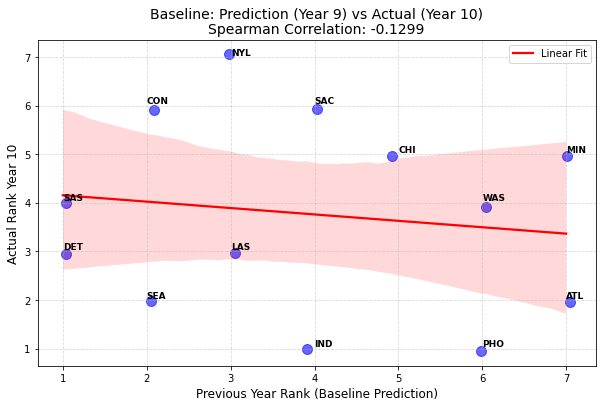

In [136]:
# --- Baseline for the final test set
y_pred_baseline_test = test_df['rank_lag1']
mae_baseline_test = mean_absolute_error(y_test, y_pred_baseline_test)
spearman_baseline_test, _ = spearmanr(y_test, y_pred_baseline_test)

print("\n--- Baseline Model Evaluation (on Test Set: Year 10) ---")
print(f"  MAE: {mae_baseline_test:.4f}")
print(f"  Spearman Rank: {spearman_baseline_test:.4f}")

plt.figure(figsize=(10, 6))

# Create Plot (Scatter + Regression Line)
# x_jitter helps to see overlapping points (e.g., two teams that were rank 1)
sns.regplot(x='rank_lag1', y='rank', data=test_df, 
            x_jitter=0.1, y_jitter=0.1, 
            scatter_kws={'s': 100, 'alpha': 0.6, 'color': 'blue'},
            line_kws={'color': 'red', 'label': 'Linear Fit'})

# Add Labels (Team Name) to each point
for i, row in test_df.iterrows():
    plt.text(row['rank_lag1'], row['rank'], row['tmID'], 
             fontsize=9, ha='left', va='bottom', fontweight='bold')

plt.title(f"Baseline: Prediction (Year 9) vs Actual (Year 10)\nSpearman Correlation: {spearman_baseline_test:.4f}", fontsize=14)
plt.xlabel("Previous Year Rank (Baseline Prediction)", fontsize=12)
plt.ylabel("Actual Rank Year 10", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


--- Evaluating all optimized models on the Test Set (Year 10) ---

--- Final Showdown: Validation vs Test Performance ---
            Model  Validation MAE  Test MAE (Year 10)  Test RMSE (Year 10)  Test Spearman  Generalization Gap
Gradient Boosting        1.662585            1.565960             1.949131       0.340732           -0.096625
    Random Forest        1.616001            1.621726             2.013023       0.204993            0.005726
         AdaBoost        1.636795            1.667556             2.014118       0.193913            0.030761
 Ridge Regression        1.542538            1.692867             2.178466       0.152360            0.150329
              SVR        1.512323            1.875235             2.450020       0.088646            0.362911
Linear Regression        2.176105            2.362403             3.035991       0.049863            0.186298


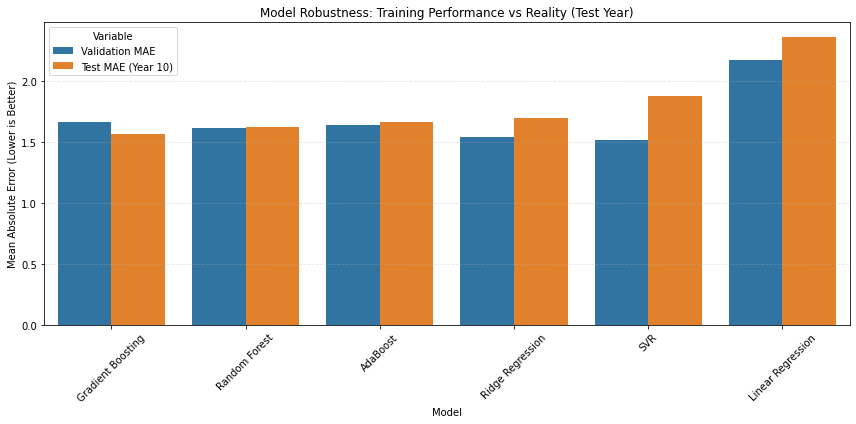


Best Model in Testing (Year 10): Gradient Boosting


In [137]:
# Prepare Test Data
X_test = test_df[best_features]
y_test = test_df[target_col]

print(f"--- Evaluating all optimized models on the Test Set (Year 10) ---")

final_comparison = []

# Iterate through the results of the Grid Search
for index, row in results_df.iterrows():
    model_name = row['Model']
    trained_model = row['Best_Estimator']
    val_mae = row['MAE']
    
    # Predict on Test Set (Year 10)
    y_pred_test = trained_model.predict(X_test)
    
    # Calculate Test Metrics
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_spearman, _ = spearmanr(y_test, y_pred_test)
    
    final_comparison.append({
        "Model": model_name,
        "Validation MAE": val_mae,
        "Test MAE (Year 10)": test_mae,
        "Test RMSE (Year 10)": test_rmse,
        "Test Spearman": test_spearman,
        "Generalization Gap": test_mae - val_mae,
        "Best_Estimator": trained_model
    })

# Create DataFrame for comparison
comparison_df = pd.DataFrame(final_comparison)
comparison_df = comparison_df.sort_values(by='Test MAE (Year 10)', ascending=True)

display_cols = ["Model", "Validation MAE", "Test MAE (Year 10)", "Test RMSE (Year 10)", "Test Spearman", "Generalization Gap"]

print("\n--- Final Showdown: Validation vs Test Performance ---")
print(comparison_df[display_cols].to_string(index=False))

# Plot Comparison
plt.figure(figsize=(12, 6))
tidy = comparison_df.melt(id_vars='Model').rename(columns=str.title)
tidy = tidy[tidy['Variable'].isin(['Validation MAE', 'Test MAE (Year 10)'])]

sns.barplot(x='Model', y='Value', hue='Variable', data=tidy)
plt.title("Model Robustness: Training Performance vs Reality (Test Year)")
plt.ylabel("Mean Absolute Error (Lower is Better)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

best_test_model_row = comparison_df.iloc[0]
final_model_name = best_test_model_row['Model']
final_model = best_test_model_row['Best_Estimator']
mae_final = best_test_model_row['Test MAE (Year 10)']

print(f"\nBest Model in Testing (Year 10): {best_test_model_row['Model']}")


In [138]:
# Generate Final Predictions with the Best Model
y_pred_final = final_model.predict(X_test)

# Create the final results DataFrame
final_results_df = test_df[['tmID', 'confID', 'year', 'rank', 'rank_lag1']].copy()
final_results_df.rename(columns={'rank': 'actual_rank', 'rank_lag1': 'baseline_rank'}, inplace=True)
final_results_df['predicted_rank_raw'] = y_pred_final

# Rank the model's raw predictions to get a 1-N ranking
final_results_df['predicted_rank_model'] = final_results_df.groupby('confID')['predicted_rank_raw'] \
                                                          .rank(method='first', ascending=True) \
                                                          .astype(int)

# Sort for easy viewing
final_results_df = final_results_df.sort_values(by=['confID', 'actual_rank'])

print("\n--- Final Predicted vs. Actual Rankings (Year 10) ---")
print(final_results_df[['confID', 'tmID', 'actual_rank', 'baseline_rank', 'predicted_rank_model']].to_string(index=False))

improvement_pct = ((mae_baseline_test - mae_final) / mae_baseline_test) * 100

print(f"\n--- Performance Comparison ---")
print(f"Baseline Error (Previous Year Rank): {mae_baseline_test:.4f}")
print(f"Model Error (With Custom Features): {mae_final:.4f}")
print(f"--------------------------------------------------")
print(f"TOTAL IMPROVEMENT: {improvement_pct:.2f}%")



--- Final Predicted vs. Actual Rankings (Year 10) ---
confID tmID  actual_rank  baseline_rank  predicted_rank_model
    EA  IND            1            4.0                     1
    EA  ATL            2            7.0                     7
    EA  DET            3            1.0                     2
    EA  WAS            4            6.0                     6
    EA  CHI            5            5.0                     5
    EA  CON            6            2.0                     3
    EA  NYL            7            3.0                     4
    WE  PHO            1            6.0                     3
    WE  SEA            2            2.0                     1
    WE  LAS            3            3.0                     2
    WE  SAS            4            1.0                     5
    WE  MIN            5            7.0                     6
    WE  SAC            6            4.0                     4

--- Performance Comparison ---
Baseline Error (Previous Year Rank): 2.4615
M

In [139]:
# Function to calculate NDCG
def calculate_ndcg(df):
    ndcg_values = []
    
    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf].copy()
        
        # Transform Rank into Relevance (Rank 1 = High Relevance)
        # Example: If 6 teams, Rank 1 gets score 6, Rank 6 gets score 1
        max_rank = conf_data['actual_rank'].max()
        
        # Create relevance arrays (1 sample, N items)
        true_relevance = [((max_rank + 1) - conf_data['actual_rank'].values)]
        predicted_scores = [((max_rank + 1) - conf_data['predicted_rank_model'].values)]
        
        # Calculate NDCG
        score = ndcg_score(true_relevance, predicted_scores)
        ndcg_values.append(score)
        
    return np.mean(ndcg_values)

# Calculate and Print
avg_ndcg = calculate_ndcg(final_results_df)
print(f"NDCG Score: {avg_ndcg:.4f} (Closer to 1.0 is better)")


NDCG Score: 0.9421 (Closer to 1.0 is better)


In [140]:
def calculate_business_metrics(df):
    precisions = []
    
    print(f"\n--- Business Metrics Analysis (Playoff Precision) ---")

    for conf in df['confID'].unique():
        conf_data = df[df['confID'] == conf]
        
        # --- Precision@4 (Playoff Accuracy) ---
        # Identify the actual teams that made Top 4
        actual_playoff_teams = set(conf_data[conf_data['actual_rank'] <= 4]['tmID'])
        
        # Identify the teams the MODEL predicted for Top 4
        predicted_playoff_teams = set(conf_data[conf_data['predicted_rank_model'] <= 4]['tmID'])
        
        # How many did we get right?
        correct_hits = len(actual_playoff_teams.intersection(predicted_playoff_teams))
        precision = correct_hits / 4.0 # Since 4 teams qualify
        precisions.append(precision)
        
        print(f"Conference {conf}: Playoff Precision = {precision*100:.0f}% ({correct_hits}/4)")
        
    avg_precision = np.mean(precisions)
    
    print(f"---------------------------------")
    print(f"AVG Playoff Precision: {avg_precision*100:.1f}%")

# Run the function
calculate_business_metrics(final_results_df)



--- Business Metrics Analysis (Playoff Precision) ---
Conference EA: Playoff Precision = 50% (2/4)
Conference WE: Playoff Precision = 75% (3/4)
---------------------------------
AVG Playoff Precision: 62.5%


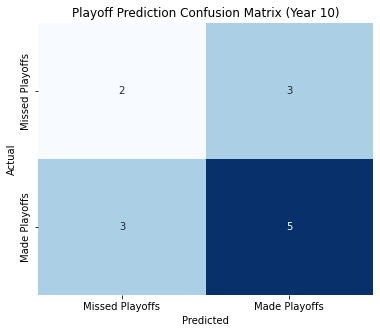

In [141]:
# Create Binary Columns for Playoffs (Top 4 = Yes, >4 = No)
final_results_df['Actual_Playoff'] = final_results_df['actual_rank'] <= 4
final_results_df['Predicted_Playoff'] = final_results_df['predicted_rank_model'] <= 4

# Generate Confusion Matrix
cm = confusion_matrix(final_results_df['Actual_Playoff'], final_results_df['Predicted_Playoff'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Missed Playoffs', 'Made Playoffs'],
            yticklabels=['Missed Playoffs', 'Made Playoffs'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Playoff Prediction Confusion Matrix (Year 10)')
plt.show()
